# Building Our First Neural Network

In this notebook, we will build our first Artificial Neural
Network (ANN) using TensorFlow and Keras.

We will:

1. Import TensorFlow
2. Prepare training and testing data
3. Build the neural network
4. Understand the layers
5. Compile the model
6. Train the model
7. Evaluate the model
8. Make predictions

In [5]:
import tensorflow as tf
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# Our Dataset

We have:

X_train → Training features
y_train → Training labels

X_test → Testing features
y_test → Testing labels

Our dataset contains 10 input features.

Therefore, our input layer will have:

input_shape = (10,)

In [6]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=7,
    n_redundant=3,
    n_classes=2,
    random_state=42
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:")
print(X_train)

print("\ny_train:")
print(y_train)

print("\nX_test:")
print(X_test)

print("\ny_test:")
print(y_test)

X_train:
[[-1.33093047 -2.36015638  2.7322271  ... -1.50675039  2.41456771
  -2.54906991]
 [ 1.32342837 -1.36551008 -0.82291403 ...  0.75953593 -0.51955286
  -0.20763858]
 [ 0.57731824 -0.97256318  0.35544099 ...  0.73464168  1.53101137
  -0.67226011]
 ...
 [-0.50358357 -0.4590864  -1.23726773 ... -2.6788245  -1.04154995
   0.74954292]
 [ 2.56195504 -1.12341084 -1.35376292 ...  0.97057341  2.35574637
   1.36978193]
 [-1.50368088 -0.7505023   1.0031621  ...  2.63072882  2.86096634
   0.8075944 ]]

y_train:
[1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 0 1 1 0 0 0 1 0
 0 0 0 1 1 0 0 1 1 0 0 1 0 1 0 0 0 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1
 1 0 0 0 1 1 0 1 0 0 0 1 0 0 1 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1
 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 1 1 1 1 1
 1 1 1 0 0 0 1 0 0 1 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 0 0 0
 1 1 0 0 0 0 0 1 0 1 1 1 0 0 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1
 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 

# Building the Neural Network

Our architecture will be:

Input Layer
     ↓
Dense Layer — 64 neurons + ReLU
     ↓
Dense Layer — 32 neurons + ReLU
     ↓
Output Layer — 1 neuron + Sigmoid

Architecture:

10 → 64 → 32 → 1

This is a binary classification problem.

Therefore:

Hidden layers → ReLU
Output layer → Sigmoid

In [7]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(10,)),
    
    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),
    
    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),
    
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling the Model

Before training, we need to compile the model.

We specify:

Optimizer:
Adam

Loss:
Binary Cross-Entropy

Metric:
Accuracy

Because this is a binary classification problem.

In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Training the Neural Network

We use model.fit() to train the neural network.

During training:

Input
 ↓
Forward Propagation
 ↓
Prediction
 ↓
Loss Calculation
 ↓
Backpropagation
 ↓
Gradient Calculation
 ↓
Weight Updates
 ↓
Repeat

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7078 - loss: 0.6092 - val_accuracy: 0.7625 - val_loss: 0.4847
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8219 - loss: 0.4476 - val_accuracy: 0.8250 - val_loss: 0.4002
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8547 - loss: 0.3696 - val_accuracy: 0.8687 - val_loss: 0.3541
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8828 - loss: 0.3221 - val_accuracy: 0.8813 - val_loss: 0.3138
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9000 - loss: 0.2828 - val_accuracy: 0.9000 - val_loss: 0.2861
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9094 - loss: 0.2553 - val_accuracy: 0.9250 - val_loss: 0.2639
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9203 - loss: 0.2336 - val_accuracy: 0.9312 - val_loss: 0.2564
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9187 - loss: 0.2190 - val_accuracy: 0.9312 - val_loss:

# Evaluating the Neural Network

After training, we evaluate the model using unseen test data.

The model has never used X_test and y_test during training.

Therefore, this gives us an estimate of how well the model
generalizes to unseen data.

In [11]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9250 - loss: 0.2285 
Test Loss: 0.2284778207540512
Test Accuracy: 0.925000011920929


# Making Predictions

The sigmoid output produces a probability between 0 and 1.

Example:

0.12 → likely class 0
0.85 → likely class 1

We can use 0.5 as the classification threshold.

In [12]:
y_prob = model.predict(X_test)

print(y_prob[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[[9.9999541e-01]
 [1.4083743e-01]
 [2.5497773e-03]
 [9.1947922e-03]
 [9.9988908e-01]
 [9.9352938e-01]
 [5.7810403e-02]
 [9.9999994e-01]
 [5.9580128e-04]
 [8.9183927e-02]]


In [13]:
y_pred = (y_prob >= 0.5).astype(int)

print(y_pred[:10])

[[1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]]


# Classification Metrics

We can evaluate our predictions using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.925
Precision: 0.9207920792079208
Recall: 0.93
F1 Score: 0.9253731343283582

Confusion Matrix:
[[92  8]
 [ 7 93]]


# Training History

The history object stores information from each epoch.

It contains values such as:

- loss
- accuracy
- val_loss
- val_accuracy

We can visualize these values to understand how the
neural network learned.

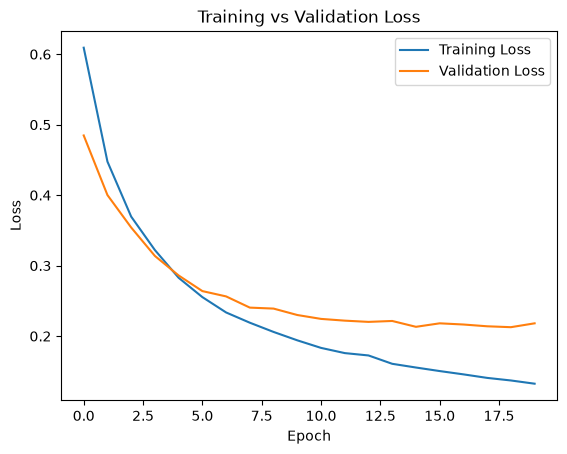

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

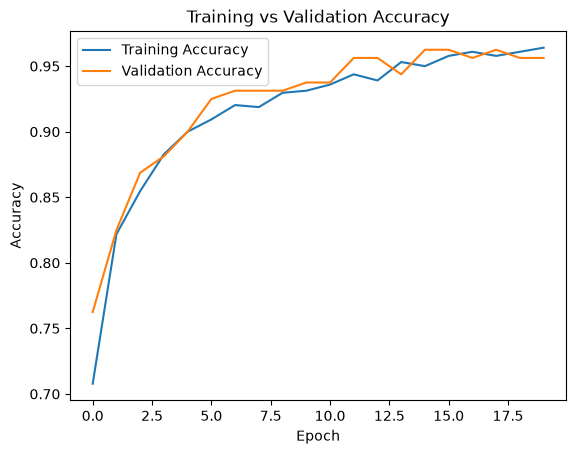

In [16]:
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()